In [49]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from skfuzzy import cmeans
import os
import glob
from tqdm import tqdm

In [50]:
# Dataset paths
dataset_root = os.path.join(os.getcwd(), "data", "KRD WBC Dataset")
img_dir = os.path.join(dataset_root, "val", "images")
mask_dir = os.path.join(dataset_root, "val", "mask")

# Get all image paths
image_paths = []
for ext in ("*.jpg", "*.jpeg", "*.png"):
    image_paths.extend(glob.glob(os.path.join(img_dir, ext)))

# Match images with masks
samples = []
for img_path in sorted(image_paths):
    stem = os.path.splitext(os.path.basename(img_path))[0]
    mask_matches = glob.glob(os.path.join(mask_dir, f"{stem}.*"))
    if mask_matches:
        samples.append((img_path, mask_matches[0]))

print(f"Found {len(samples)} image-mask pairs")

Found 119 image-mask pairs


In [51]:
def load_image_and_mask(img_path, mask_path, img_size=(200, 200)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)
    
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, img_size, interpolation=cv2.INTER_NEAREST)
    mask = (mask > 0).astype(np.uint8)
    
    return img, mask

In [52]:
def segment_kmeans(img, n_clusters=3):
    """K-Means clustering segmentation."""
    pixels = img.reshape((-1, 3)).astype(np.float32)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pixels)
    return labels.reshape(img.shape[:2])

def segment_fcm(img, n_clusters=3):
    """Fuzzy C-Means clustering segmentation."""
    pixels = img.reshape((-1, 3)).T.astype(np.float64)
    cntr, u, u0, d, jm, p, fpc = cmeans(pixels, n_clusters, 2, error=0.005, maxiter=1000)
    labels = np.argmax(u, axis=0)
    return labels.reshape(img.shape[:2])

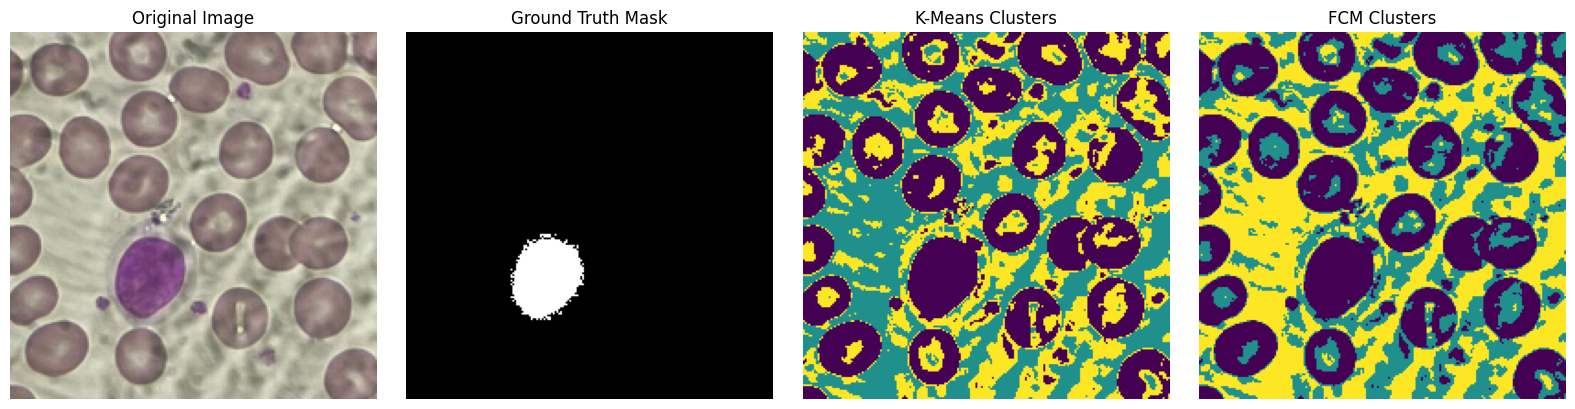

In [53]:
random_idx = np.random.randint(0, len(samples))
img_path, mask_path = samples[random_idx]
img, gt_mask = load_image_and_mask(img_path, mask_path)

kmeans_labels = segment_kmeans(img, n_clusters=3)
fcm_labels = segment_fcm(img, n_clusters=3)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(gt_mask, cmap="gray")
axes[1].set_title("Ground Truth Mask")
axes[1].axis("off")

axes[2].imshow(kmeans_labels, cmap="viridis")
axes[2].set_title("K-Means Clusters")
axes[2].axis("off")

axes[3].imshow(fcm_labels, cmap="viridis")
axes[3].set_title("FCM Clusters")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def extract_boundary(binary_mask):
    kernel = np.ones((3, 3), np.uint8)
    boundary = cv2.morphologyEx(binary_mask.astype(np.uint8), cv2.MORPH_GRADIENT, kernel)
    return (boundary > 0).astype(np.uint8)

def calculate_boundary_metrics(boundary_gt, boundary_pred):
    TP = np.logical_and(boundary_gt, boundary_pred).sum()
    TN = np.logical_and(~boundary_gt.astype(bool), ~boundary_pred.astype(bool)).sum()
    FP = np.logical_and(~boundary_gt.astype(bool), boundary_pred).sum()
    FN = np.logical_and(boundary_gt, ~boundary_pred.astype(bool)).sum()
    
    accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

In [43]:
kmeans_metrics = {"accuracy": [], "precision": [], "recall": [], "f1_score": []}
fcm_metrics = {"accuracy": [], "precision": [], "recall": [], "f1_score": []}

for img_path, mask_path in tqdm(samples, desc="Processing images"):
    img, gt_mask = load_image_and_mask(img_path, mask_path)
    
    kmeans_labels = segment_kmeans(img, n_clusters=3)
    fcm_labels = segment_fcm(img, n_clusters=3)
    
    kmeans_pred = (kmeans_labels > 0).astype(np.uint8)
    fcm_pred = (fcm_labels > 0).astype(np.uint8)
    
    gt_boundary = extract_boundary(gt_mask)
    kmeans_boundary = extract_boundary(kmeans_pred)
    fcm_boundary = extract_boundary(fcm_pred)
    
    km_metrics = calculate_boundary_metrics(gt_boundary, kmeans_boundary)
    fm_metrics = calculate_boundary_metrics(gt_boundary, fcm_boundary)
    
    for key in kmeans_metrics:
        kmeans_metrics[key].append(km_metrics[key])
        fcm_metrics[key].append(fm_metrics[key])

print("\nK-MEANS Results:")
print(f"Accuracy:  {np.mean(kmeans_metrics['accuracy']):.4f}")
print(f"Precision: {np.mean(kmeans_metrics['precision']):.4f}")
print(f"Recall:    {np.mean(kmeans_metrics['recall']):.4f}")
print(f"F1-Score:  {np.mean(kmeans_metrics['f1_score']):.4f}")

print("\nFuzzy C-Means Results:")
print(f"Accuracy:  {np.mean(fcm_metrics['accuracy']):.4f}")
print(f"Precision: {np.mean(fcm_metrics['precision']):.4f}")
print(f"Recall:    {np.mean(fcm_metrics['recall']):.4f}")
print(f"F1-Score:  {np.mean(fcm_metrics['f1_score']):.4f}")

Processing images: 100%|██████████| 119/119 [01:38<00:00,  1.21it/s]


K-MEANS Results:
Accuracy:  0.6675
Precision: 0.0285
Recall:    0.5413
F1-Score:  0.0520

Fuzzy C-Means Results:
Accuracy:  0.6573
Precision: 0.0319
Recall:    0.5712
F1-Score:  0.0563
